# Clustering Comparison: make_moons

Comparing all 5 methods on `sklearn.datasets.make_moons()` (1,000 points,
2 interleaving half-moon classes, `noise=0.07`). This synthetic dataset is
specifically designed to be **non-convex**, which is expected to separate
methods that assume convex/Gaussian clusters (K-Means++, GMM) from those
that don't (DBSCAN, HDBSCAN, Spectral Clustering with a suitable affinity).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sc4020 import data, clustering, metrics, viz, hyperparams

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
METRIC_COLS = [
    "method", "fit_seconds", "n_clusters_found", "noise_ratio",
    "silhouette", "davies_bouldin", "calinski_harabasz",
]
EXTERNAL_COLS = ["adjusted_rand_index", "normalized_mutual_info", "adjusted_mutual_info", "fowlkes_mallows"]


In [2]:
ds = data.load_make_moons(n_samples=1000, noise=0.07, random_state=42)
print(f"{ds.name}: X={ds.X.shape}, classes={ds.class_names}, n_true_clusters={ds.n_true_clusters}")

make_moons: X=(1000, 2), classes=['moon_0', 'moon_1'], n_true_clusters=2


## Exploratory look

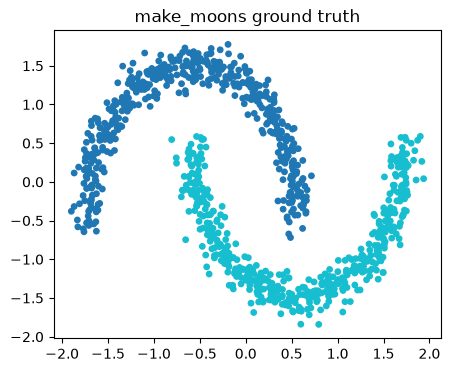

In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(ds.X[:, 0], ds.X[:, 1], c=ds.y, cmap="tab10", s=15)
ax.set_title("make_moons ground truth")
plt.show()

## 2D embedding for visualization

The data is already 2D, so no dimensionality reduction is needed for plotting
— the standardized features are used directly, both for clustering and viz.

In [4]:
X_2d = ds.X

## DBSCAN eps selection

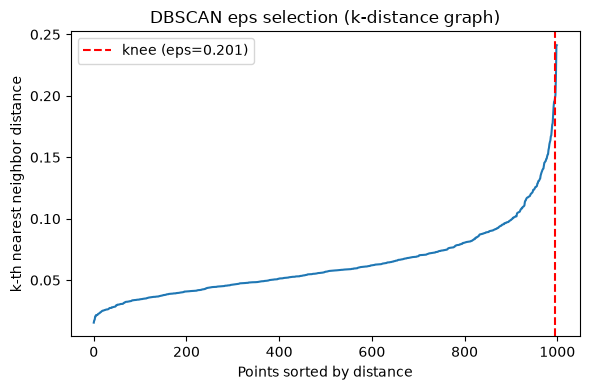

In [5]:
ms = hyperparams.default_min_samples(ds.X.shape[1])
kd = hyperparams.select_dbscan_eps(ds.X, min_samples=ms)
viz.plot_k_distance(kd.distances, kd.knee_idx, kd.eps_at_knee)
plt.show()

## Fit all 5 methods

K = 2 (true class count). Spectral Clustering uses a nearest-neighbors
affinity — required to respect the moons' manifold shape (an RBF affinity
would blur the two interleaving arcs together).

In [6]:
results = clustering.run_all_methods(ds.X, ds.n_true_clusters, spectral_affinity="nearest_neighbors")
for name, r in results.items():
    print(f"{name:22s} params={r.params}  fit_seconds={r.fit_seconds:.3f}")

KMeans++               params={'n_clusters': 2}  fit_seconds=0.026
DBSCAN                 params={'eps': 0.15056383370348303, 'min_samples': 4}  fit_seconds=0.004
HDBSCAN                params={'min_cluster_size': 50}  fit_seconds=0.013
GMM                    params={'n_components': 2}  fit_seconds=0.068
Spectral Clustering    params={'n_clusters': 2, 'affinity': 'nearest_neighbors'}  fit_seconds=0.015


## Metrics

In [7]:
results_df = metrics.build_results_table(ds.name, ds.X, results, ds.y)
display(results_df[METRIC_COLS])
display(results_df[["method"] + EXTERNAL_COLS])

,method,fit_seconds,n_clusters_found,noise_ratio,silhouette,davies_bouldin,calinski_harabasz
0,KMeans++,0.026500,2,0.000,0.495011,0.811856,1379.803922
1,DBSCAN,0.004443,2,0.009,0.392346,1.012962,872.064603
2,HDBSCAN,0.013070,2,0.027,0.409269,0.969207,931.859499
3,GMM,0.067627,2,0.000,0.495147,0.811785,1379.219134
4,Spectral Clustering,0.014513,2,0.000,0.387472,1.023266,861.968496


,method,adjusted_rand_index,normalized_mutual_info,adjusted_mutual_info,fowlkes_mallows
0,KMeans++,0.481117,0.382784,0.382337,0.740312
1,DBSCAN,0.982066,0.959843,0.959785,0.990983
2,HDBSCAN,0.946676,0.904251,0.904121,0.972947
3,GMM,0.489489,0.390213,0.389772,0.744497
4,Spectral Clustering,1.000000,1.000000,1.000000,1.000000


## Cluster visualizations vs. ground truth

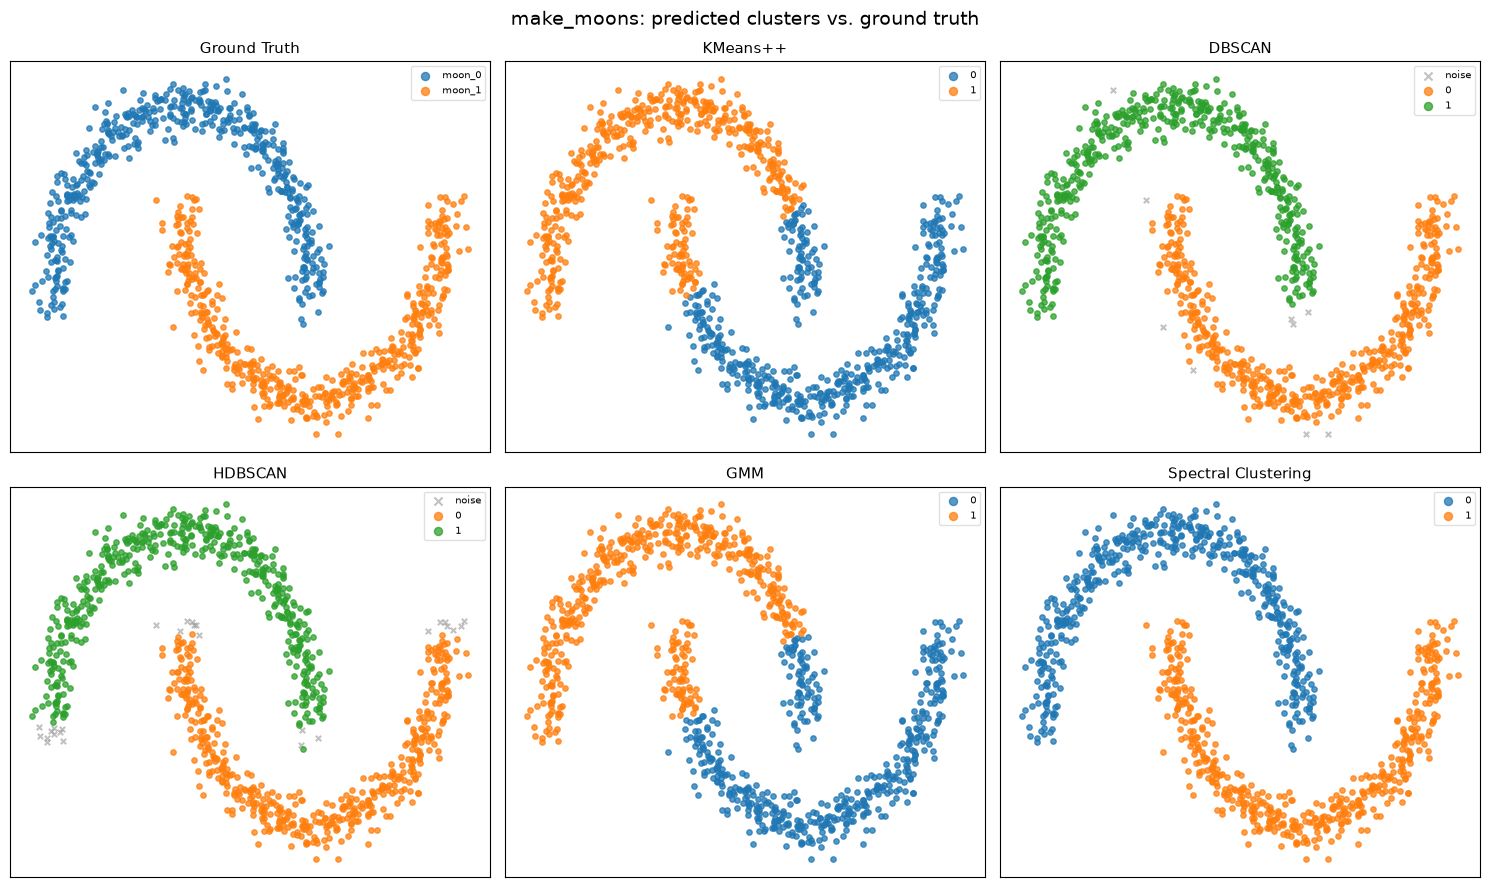

In [8]:
fig = viz.plot_cluster_grid(X_2d, results, y_true=ds.y, class_names=ds.class_names,
                             title="make_moons: predicted clusters vs. ground truth")
plt.show()

## Discussion

- **Spectral Clustering (nearest-neighbors affinity), DBSCAN, and HDBSCAN**
  should all recover the two moons almost perfectly (ARI/NMI close to 1.0):
  they don't assume convex clusters, so they can follow the curved,
  interleaving shape.
- **K-Means++ and GMM** should score much lower: both assume roughly
  spherical/Gaussian clusters, so they instead split the data with a straight
  decision boundary that cuts across both moons — clearly visible as
  mismatched colors relative to the ground-truth panel.
- Note that internal metrics (Silhouette, Davies-Bouldin, Calinski-Harabasz)
  can actually favor K-Means++/GMM here even though their *external* metrics
  (ARI/NMI) are worse — internal metrics assume convex, well-separated
  clusters too, so they reward the "wrong but convex" answer. This is a good
  illustration of why external metrics matter whenever ground truth is
  available, and why no single metric tells the whole story.